# Vision Transformers

## Feature Extraction Simulation

In [1]:
%pwd

'/Users/vasim/Programming/hands-on-transformers-for-nlp-and-cv/chapter-16'

In [2]:
from PIL import Image

image_path = "data/nyc_coffee_cup.jpg"

In [3]:
image = Image.open(image_path)

In [4]:
%matplotlib inline

from torchvision.transforms import transforms
import matplotlib.pyplot as plt

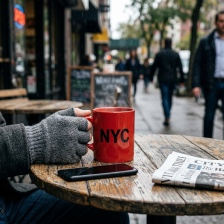

In [5]:
image

In [6]:
# Define transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [7]:
pixel_values = transform(image)

In [8]:
pixel_values

tensor([[[0.0235, 0.0039, 0.0078,  ..., 0.5333, 0.4745, 0.4824],
         [0.0157, 0.0039, 0.0039,  ..., 0.5255, 0.5137, 0.5137],
         [0.0039, 0.0000, 0.0039,  ..., 0.5608, 0.5569, 0.5412],
         ...,
         [0.0706, 0.0549, 0.0235,  ..., 0.5059, 0.5294, 0.5059],
         [0.0941, 0.0863, 0.0549,  ..., 0.5098, 0.5176, 0.5059],
         [0.0000, 0.0196, 0.0353,  ..., 0.4980, 0.4902, 0.5176]],

        [[0.0314, 0.0235, 0.0235,  ..., 0.4784, 0.4353, 0.4471],
         [0.0353, 0.0235, 0.0196,  ..., 0.4824, 0.4824, 0.4902],
         [0.0392, 0.0235, 0.0196,  ..., 0.5333, 0.5451, 0.5294],
         ...,
         [0.1569, 0.1529, 0.1373,  ..., 0.5059, 0.5255, 0.5020],
         [0.2157, 0.2196, 0.1961,  ..., 0.5098, 0.5137, 0.5020],
         [0.1412, 0.1725, 0.1922,  ..., 0.4980, 0.4863, 0.5137]],

        [[0.0118, 0.0078, 0.0196,  ..., 0.4784, 0.4392, 0.4588],
         [0.0196, 0.0078, 0.0235,  ..., 0.4745, 0.4745, 0.4902],
         [0.0353, 0.0235, 0.0235,  ..., 0.5020, 0.5176, 0.

In [9]:
# Add an extra dimension
pixel_values = pixel_values.unsqueeze(0)

In [10]:
pixel_values

tensor([[[[0.0235, 0.0039, 0.0078,  ..., 0.5333, 0.4745, 0.4824],
          [0.0157, 0.0039, 0.0039,  ..., 0.5255, 0.5137, 0.5137],
          [0.0039, 0.0000, 0.0039,  ..., 0.5608, 0.5569, 0.5412],
          ...,
          [0.0706, 0.0549, 0.0235,  ..., 0.5059, 0.5294, 0.5059],
          [0.0941, 0.0863, 0.0549,  ..., 0.5098, 0.5176, 0.5059],
          [0.0000, 0.0196, 0.0353,  ..., 0.4980, 0.4902, 0.5176]],

         [[0.0314, 0.0235, 0.0235,  ..., 0.4784, 0.4353, 0.4471],
          [0.0353, 0.0235, 0.0196,  ..., 0.4824, 0.4824, 0.4902],
          [0.0392, 0.0235, 0.0196,  ..., 0.5333, 0.5451, 0.5294],
          ...,
          [0.1569, 0.1529, 0.1373,  ..., 0.5059, 0.5255, 0.5020],
          [0.2157, 0.2196, 0.1961,  ..., 0.5098, 0.5137, 0.5020],
          [0.1412, 0.1725, 0.1922,  ..., 0.4980, 0.4863, 0.5137]],

         [[0.0118, 0.0078, 0.0196,  ..., 0.4784, 0.4392, 0.4588],
          [0.0196, 0.0078, 0.0235,  ..., 0.4745, 0.4745, 0.4902],
          [0.0353, 0.0235, 0.0235,  ..., 0

In [11]:
patch_size = 16

### What is `torch.Tensor.unfold`

`unfold` is a tensor method that extracts sliding local blocks from a specified dimension without copying all data into a new tensor. It is useful for creating windowed views of input data, such as image patches or overlapping segments in sequences.

### Parameters

- `dimension`: the axis along which to extract windows.
- `size`: the length of each slice or window.
- `step`: the stride between the starts of consecutive windows.

For example, `tensor.unfold(2, 16, 16)` means:
- take windows along dimension 2,
- each window has size 16,
- move 16 steps for the next window.

### Output shape

If the original size along the selected dimension is `L`, and you unfold with `size=S` and `step=K`, the number of windows is:
- `n = floor((L - S) / K) + 1`

The result tensor has an extra dimension appended at the end for the window contents. So a tensor of shape `[B, C, H, W]` unfolded on height and width becomes:
- `[B, C, H_windows, W_windows, S, S]`

This means you now have a grid of patches, where each patch is a slice of length `S` along the unfolded dimension.

### How it works

`unfold` does not reshape the tensor in the usual flattening sense. Instead, it creates a view where one dimension indexes the window positions and another dimension contains the window values. That is why it is efficient for patch extraction and local operations.

### Example usage in patch extraction

For image patching, apply `unfold` twice:
- once on the height dimension,
- once on the width dimension.

This converts a tensor of shape `[batch, channels, height, width]` into a tensor of patches:
- `[batch, channels, num_patches_h, num_patches_w, patch_size, patch_size]`

Then you can reshape or permute to get a list of flattened patches if needed.

### Common use cases

- extracting image patches for Vision Transformers
- creating sliding windows over time series data
- building local receptive fields without explicit loops
- reducing operations to patch-based processing in CNN-like pipelines

In [12]:
# pixel_values[0][0][0]

In [13]:
# Assuming pixel values is your input image tensor of shape
# [batch_size, num_channels, height, width
patches = pixel_values.unfold(
    2, patch_size, patch_size
).unfold(
    3, patch_size, patch_size
)

In [14]:
len(patches)

1

In [15]:
patches[0][0][0]

tensor([[[0.0235, 0.0039, 0.0078,  ..., 0.2471, 0.3608, 0.3765],
         [0.0157, 0.0039, 0.0039,  ..., 0.2392, 0.3373, 0.3765],
         [0.0039, 0.0000, 0.0039,  ..., 0.2353, 0.3176, 0.3412],
         ...,
         [0.0431, 0.0157, 0.0039,  ..., 0.3020, 0.5569, 0.8353],
         [0.0353, 0.0157, 0.0039,  ..., 0.2941, 0.5608, 0.8588],
         [0.0314, 0.0078, 0.0039,  ..., 0.3020, 0.5647, 0.8588]],

        [[0.3412, 0.3176, 0.3137,  ..., 0.0627, 0.0941, 0.1020],
         [0.3255, 0.3216, 0.3490,  ..., 0.0902, 0.1098, 0.1137],
         [0.2980, 0.2902, 0.3451,  ..., 0.1216, 0.1294, 0.1333],
         ...,
         [0.9255, 0.9647, 0.9647,  ..., 0.2745, 0.2745, 0.2667],
         [0.9451, 0.9804, 0.9804,  ..., 0.2980, 0.2745, 0.2784],
         [0.9804, 1.0000, 1.0000,  ..., 0.3176, 0.2745, 0.2902]],

        [[0.1020, 0.0667, 0.0275,  ..., 0.1843, 0.1569, 0.0706],
         [0.1137, 0.0745, 0.0314,  ..., 0.1647, 0.1412, 0.0706],
         [0.1333, 0.0902, 0.0392,  ..., 0.1333, 0.1216, 0.

#### Deciphering `patches[0][0][0][0][0]`

The `patches` tensor has shape **`[1, 3, 14, 14, 16, 16]`**, so each index
drills one level deeper into the data:

| Index | Axis | Meaning | Shape after |
|-------|------|---------|-------------|
| `[0]` | batch | The first (and only) image in the batch | `[3, 14, 14, 16, 16]` |
| `[0]` | channel | The **Red** channel (0=R, 1=G, 2=B) | `[14, 14, 16, 16]` |
| `[0]` | patch row | The **first row** of the 14×14 patch grid (topmost patches) | `[14, 16, 16]` |
| `[0]` | patch column | The **first patch in that row** → the **top-left** 16×16 patch | `[16, 16]` |
| `[0]` | pixel row | The **first row** of pixels inside that 16×16 patch | `[16]` |

So the output is **16 pixel values** — the top row of the top-left 16×16 patch
from the Red channel. Each value is a normalized pixel intensity (0–1 range,
from `ToTensor()`).

In [16]:
# Reshaping the patches tensor for easy viewing
patches_reshaped = patches.permute(
    0, 2, 3, 1, 4, 5
    ).contiguous().view(-1, 3, patch_size, patch_size)

The goal of that line is to convert the 6D `patches` tensor into a flat list of standalone image patches. Here's the step-by-step breakdown:

**Starting shape:** `[1, 3, 14, 14, 16, 16]`

| Dim | Meaning |
|-----|---------|
| 1 | batch |
| 3 | channels (RGB) |
| 14 | patch rows |
| 14 | patch columns |
| 16 | patch height (px) |
| 16 | patch width (px) |

**`permute(0, 2, 3, 1, 4, 5)`** — reorders to `[1, 14, 14, 3, 16, 16]`

This moves the channel dimension (1) next to the pixel dimensions, so each patch's RGB data is grouped together:

```
Before: [B,  C,  grid_h,  grid_w,  px_h,  px_w]
After:  [B,  grid_h,  grid_w,  C,  px_h,  px_w]
```

**`.contiguous()`** — makes the tensor contiguous in memory so `.view()` can work.

**`.view(-1, 3, 16, 16)`** — flattens the batch and grid dimensions into one:

```
[1, 14, 14, 3, 16, 16]  →  [196, 3, 16, 16]
```

The `-1` computes `1 × 14 × 14 = 196` (the total number of patches).

**Final result:** a tensor of **196 individual RGB patches**, each `3×16×16`:

```
patches_reshaped[0]   →  top-left patch
patches_reshaped[1]   →  next patch to the right
...
patches_reshaped[195] →  bottom-right patch
```

This format is perfect for:
- Visualizing patches individually with `imshow`
- Iterating over patches in a loop
- Feeding each patch through a linear projection (the next step in a ViT)

In [17]:
patches_reshaped

tensor([[[[0.0235, 0.0039, 0.0078,  ..., 0.2471, 0.3608, 0.3765],
          [0.0157, 0.0039, 0.0039,  ..., 0.2392, 0.3373, 0.3765],
          [0.0039, 0.0000, 0.0039,  ..., 0.2353, 0.3176, 0.3412],
          ...,
          [0.0431, 0.0157, 0.0039,  ..., 0.3020, 0.5569, 0.8353],
          [0.0353, 0.0157, 0.0039,  ..., 0.2941, 0.5608, 0.8588],
          [0.0314, 0.0078, 0.0039,  ..., 0.3020, 0.5647, 0.8588]],

         [[0.0314, 0.0235, 0.0235,  ..., 0.2471, 0.3333, 0.3529],
          [0.0353, 0.0235, 0.0196,  ..., 0.2392, 0.3255, 0.3608],
          [0.0392, 0.0235, 0.0196,  ..., 0.2392, 0.3294, 0.3490],
          ...,
          [0.0353, 0.0157, 0.0157,  ..., 0.1882, 0.2235, 0.3765],
          [0.0431, 0.0235, 0.0196,  ..., 0.1765, 0.2275, 0.4000],
          [0.0510, 0.0235, 0.0196,  ..., 0.1843, 0.2431, 0.4078]],

         [[0.0118, 0.0078, 0.0196,  ..., 0.2471, 0.3020, 0.2980],
          [0.0196, 0.0078, 0.0235,  ..., 0.2392, 0.2980, 0.3137],
          [0.0353, 0.0235, 0.0235,  ..., 0

Great question. The two sets of dimensions operate at **different scales**:

| Dimensions | What they represent | Values |
|------------|-------------------|--------|
| **Grid** (dim 2 & 3) | Where the patch is in the **14×14 layout** of patches across the image | 0–13 (patch position) |
| **Pixel** (dim 4 & 5) | Where the pixel is **inside a single 16×16 patch** | 0–15 (pixel position) |

Think of it like a **map vs. a tile**:

```
patches shape: [1, 3, 14, 14, 16, 16]
                │  │   ▲   ▲   │   │
                │  │   │   │   │   └── pixel column inside the patch
                │  │   │   │   └────── pixel row inside the patch
                │  │   │   └────────── patch column in the grid (0–13)
                │  │   └────────────── patch row in the grid (0–13)
                │  └────────────────── RGB channel
                └───────────────────── batch
```

**Visual analogy:**

```
                224 px
    ┌──────────────────────────────┐
    │  ┌──────────┐                │
    │  │ 16 px    │ ← [0][0]       │  ← grid row 0
    │  │ ← [0]→   │                │
    │  │  16 px   │                │
    │  └──────────┘                │
    │              ┌──────────┐    │
    │              │          │    │
    │              │ [0][1]   │    │  ← grid row 0, col 1
    │              │          │    │
    │              └──────────┘    │
    │                              │
    │         ← grid row 13 →     │
    └──────────────────────────────┘
```

- `patches[0, 0, **0, 0**, :, :]` — the **top-left patch** (grid position 0,0), all 16×16 pixels
- `patches[0, 0, **0, 1**, :, :]` — the **patch immediately to the right** (grid position 0,1)
- `patches[0, 0, **1, 0**, :, :]` — the **patch one row down** (grid position 1,0)
- `patches[0, 0, 0, 0, **0, 0**]` — the **top-left pixel** of the top-left patch
- `patches[0, 0, 0, 0, **0, 1**]` — the **next pixel to the right** within that same patch

So the `permute(0, 2, 3, 1, 4, 5)` is saying: "group grid positions together, then channels, then pixel positions" — which lets you flatten the 14×14 grid into a single list of 196 patches, each with its own `[3, 16, 16]` structure.

In [18]:
to_pil = transforms.ToPILImage()

In [19]:
patches_reshaped.size()

torch.Size([196, 3, 16, 16])

In [20]:
patches_reshaped.shape

torch.Size([196, 3, 16, 16])

Displaying patch 1/196


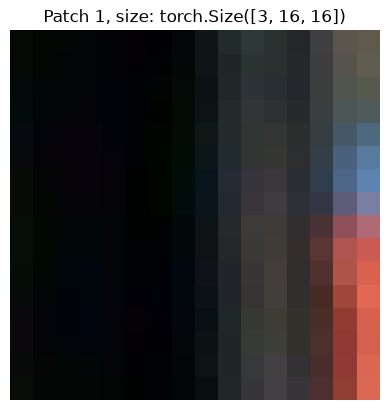

Displaying patch 2/196


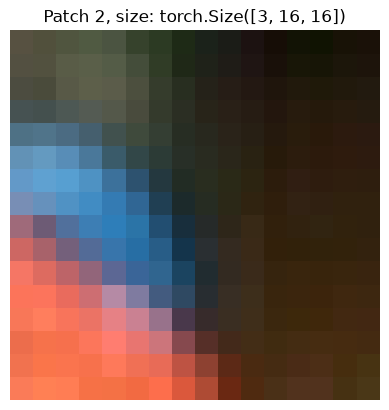

Displaying patch 3/196


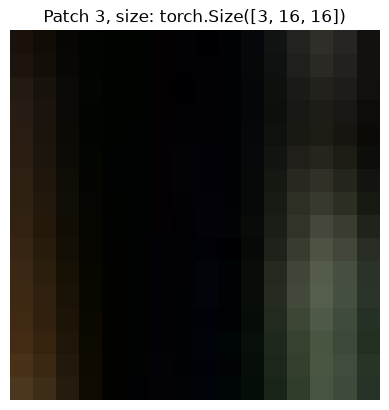

Displaying patch 4/196


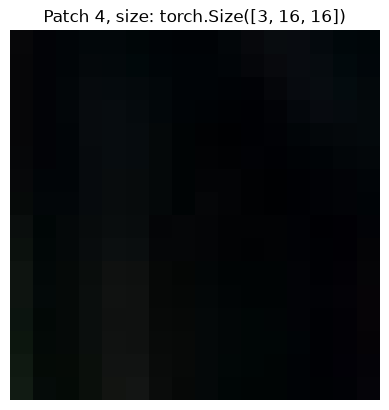

In [21]:
for i in range(patches_reshaped.size(0)):
    print(f"Displaying patch {i+1}/{patches_reshaped.size(0)}")
    patch_size = patches_reshaped[i].shape
    plt.title(f"Patch {i+1}, size: {patch_size}")
    plt.imshow(to_pil(patches_reshaped[i]))
    plt.axis("off")
    plt.show()

    if i >= 3:
        break

## Installing Feature Extractor

In [22]:
!uv add transformers -q

In [23]:
from transformers import (
    ViTImageProcessor,
    ViTForImageClassification
)
import requests

/Users/vasim/Programming/hands-on-transformers-for-nlp-and-cv/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
model_name = "google/vit-base-patch16-224"

feature_processor = ViTImageProcessor.from_pretrained(
    model_name
)
classifier = ViTForImageClassification.from_pretrained(
    model_name
)

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 11575.92it/s]


In [25]:
inputs = feature_processor(images=image, return_tensors="pt")
inputs

{'pixel_values': tensor([[[[-0.9529, -0.9922, -0.9843,  ...,  0.0667, -0.0510, -0.0353],
          [-0.9686, -0.9922, -0.9922,  ...,  0.0510,  0.0275,  0.0275],
          [-0.9922, -1.0000, -0.9922,  ...,  0.1216,  0.1137,  0.0824],
          ...,
          [-0.8588, -0.8902, -0.9529,  ...,  0.0118,  0.0588,  0.0118],
          [-0.8118, -0.8275, -0.8902,  ...,  0.0196,  0.0353,  0.0118],
          [-1.0000, -0.9608, -0.9294,  ..., -0.0039, -0.0196,  0.0353]],

         [[-0.9373, -0.9529, -0.9529,  ..., -0.0431, -0.1294, -0.1059],
          [-0.9294, -0.9529, -0.9608,  ..., -0.0353, -0.0353, -0.0196],
          [-0.9216, -0.9529, -0.9608,  ...,  0.0667,  0.0902,  0.0588],
          ...,
          [-0.6863, -0.6941, -0.7255,  ...,  0.0118,  0.0510,  0.0039],
          [-0.5686, -0.5608, -0.6078,  ...,  0.0196,  0.0275,  0.0039],
          [-0.7176, -0.6549, -0.6157,  ..., -0.0039, -0.0275,  0.0275]],

         [[-0.9765, -0.9843, -0.9608,  ..., -0.0431, -0.1216, -0.0824],
          [-0

In [26]:
outputs = classifier(**inputs)
outputs

ImageClassifierOutput(loss=None, logits=tensor([[-1.1288e+00, -5.5756e-01, -1.5567e+00, -1.3101e+00, -5.8843e-01,
         -1.5344e+00, -1.7410e+00, -1.8962e+00, -1.8121e+00, -2.0072e+00,
         -1.5723e+00, -1.7178e+00, -1.8666e+00, -1.7056e+00, -1.6707e+00,
         -9.8119e-01, -6.7786e-01, -1.7026e+00, -1.6719e+00, -1.2583e+00,
         -1.3638e+00, -1.1015e+00, -1.6210e+00, -1.5375e+00, -1.3533e+00,
         -1.2028e+00, -8.9297e-02, -3.4615e-01, -6.2297e-01, -7.7859e-01,
         -1.7597e+00, -1.0814e+00, -1.7800e+00, -2.0764e+00, -8.3730e-01,
         -1.7238e+00, -2.6275e-01, -1.8172e+00, -9.1032e-01, -1.1190e+00,
         -1.0625e+00, -9.2219e-01, -1.3375e+00, -1.3699e+00, -2.3913e-01,
         -1.5224e+00, -1.1827e+00, -1.1833e+00, -1.0774e+00, -1.7358e+00,
         -1.0469e+00,  8.9774e-02, -4.2469e-01, -1.2435e+00, -1.1599e+00,
         -1.4301e+00, -1.0391e+00, -1.3216e+00, -1.4284e+00, -1.0975e+00,
         -1.3484e+00, -1.0535e+00, -1.6283e+00, -1.3372e+00, -1.6257e+00

In [27]:
logits = outputs.logits
logits

tensor([[-1.1288e+00, -5.5756e-01, -1.5567e+00, -1.3101e+00, -5.8843e-01,
         -1.5344e+00, -1.7410e+00, -1.8962e+00, -1.8121e+00, -2.0072e+00,
         -1.5723e+00, -1.7178e+00, -1.8666e+00, -1.7056e+00, -1.6707e+00,
         -9.8119e-01, -6.7786e-01, -1.7026e+00, -1.6719e+00, -1.2583e+00,
         -1.3638e+00, -1.1015e+00, -1.6210e+00, -1.5375e+00, -1.3533e+00,
         -1.2028e+00, -8.9297e-02, -3.4615e-01, -6.2297e-01, -7.7859e-01,
         -1.7597e+00, -1.0814e+00, -1.7800e+00, -2.0764e+00, -8.3730e-01,
         -1.7238e+00, -2.6275e-01, -1.8172e+00, -9.1032e-01, -1.1190e+00,
         -1.0625e+00, -9.2219e-01, -1.3375e+00, -1.3699e+00, -2.3913e-01,
         -1.5224e+00, -1.1827e+00, -1.1833e+00, -1.0774e+00, -1.7358e+00,
         -1.0469e+00,  8.9774e-02, -4.2469e-01, -1.2435e+00, -1.1599e+00,
         -1.4301e+00, -1.0391e+00, -1.3216e+00, -1.4284e+00, -1.0975e+00,
         -1.3484e+00, -1.0535e+00, -1.6283e+00, -1.3372e+00, -1.6257e+00,
         -1.4261e+00, -1.8167e+00, -1.

### Model Prediction

In [28]:
predicted_class_idx = logits.argmax(-1).item()
predicted_class_idx

504

In [29]:
classifier.config.id2label[predicted_class_idx]

'coffee mug'

### Configuration and Shapes

In [30]:
feature_processor

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [31]:
inputs["pixel_values"].shape

torch.Size([1, 3, 224, 224])

In [32]:
classifier

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear

In [33]:
outputs.logits.shape

torch.Size([1, 1000])

In [34]:
classifier.config.id2label

{0: 'tench, Tinca tinca',
 1: 'goldfish, Carassius auratus',
 2: 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias',
 3: 'tiger shark, Galeocerdo cuvieri',
 4: 'hammerhead, hammerhead shark',
 5: 'electric ray, crampfish, numbfish, torpedo',
 6: 'stingray',
 7: 'cock',
 8: 'hen',
 9: 'ostrich, Struthio camelus',
 10: 'brambling, Fringilla montifringilla',
 11: 'goldfinch, Carduelis carduelis',
 12: 'house finch, linnet, Carpodacus mexicanus',
 13: 'junco, snowbird',
 14: 'indigo bunting, indigo finch, indigo bird, Passerina cyanea',
 15: 'robin, American robin, Turdus migratorius',
 16: 'bulbul',
 17: 'jay',
 18: 'magpie',
 19: 'chickadee',
 20: 'water ouzel, dipper',
 21: 'kite',
 22: 'bald eagle, American eagle, Haliaeetus leucocephalus',
 23: 'vulture',
 24: 'great grey owl, great gray owl, Strix nebulosa',
 25: 'European fire salamander, Salamandra salamandra',
 26: 'common newt, Triturus vulgaris',
 27: 'eft',
 28: 'spotted salamander, Ambystoma 

In [35]:
logits[0]

tensor([-1.1288e+00, -5.5756e-01, -1.5567e+00, -1.3101e+00, -5.8843e-01,
        -1.5344e+00, -1.7410e+00, -1.8962e+00, -1.8121e+00, -2.0072e+00,
        -1.5723e+00, -1.7178e+00, -1.8666e+00, -1.7056e+00, -1.6707e+00,
        -9.8119e-01, -6.7786e-01, -1.7026e+00, -1.6719e+00, -1.2583e+00,
        -1.3638e+00, -1.1015e+00, -1.6210e+00, -1.5375e+00, -1.3533e+00,
        -1.2028e+00, -8.9297e-02, -3.4615e-01, -6.2297e-01, -7.7859e-01,
        -1.7597e+00, -1.0814e+00, -1.7800e+00, -2.0764e+00, -8.3730e-01,
        -1.7238e+00, -2.6275e-01, -1.8172e+00, -9.1032e-01, -1.1190e+00,
        -1.0625e+00, -9.2219e-01, -1.3375e+00, -1.3699e+00, -2.3913e-01,
        -1.5224e+00, -1.1827e+00, -1.1833e+00, -1.0774e+00, -1.7358e+00,
        -1.0469e+00,  8.9774e-02, -4.2469e-01, -1.2435e+00, -1.1599e+00,
        -1.4301e+00, -1.0391e+00, -1.3216e+00, -1.4284e+00, -1.0975e+00,
        -1.3484e+00, -1.0535e+00, -1.6283e+00, -1.3372e+00, -1.6257e+00,
        -1.4261e+00, -1.8167e+00, -1.8975e+00, -8.3

In [36]:
import torch 
import pandas as pd

In [37]:
probs = torch.nn.functional.softmax(logits, dim=-1)

In [38]:
top_5_probs, top_5_labels = torch.topk(probs, 5)
top_5_probs = top_5_probs.detach().cpu().numpy()
top_5_labels = top_5_labels.detach().cpu().numpy()

In [39]:
top_5_probs

array([[0.7677374 , 0.11205141, 0.03123471, 0.00798096, 0.00774207]],
      dtype=float32)

In [40]:
top_5_labels

array([[504, 968, 967, 487, 918]])

In [41]:
id2label = classifier.config.id2label
id2label

{0: 'tench, Tinca tinca',
 1: 'goldfish, Carassius auratus',
 2: 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias',
 3: 'tiger shark, Galeocerdo cuvieri',
 4: 'hammerhead, hammerhead shark',
 5: 'electric ray, crampfish, numbfish, torpedo',
 6: 'stingray',
 7: 'cock',
 8: 'hen',
 9: 'ostrich, Struthio camelus',
 10: 'brambling, Fringilla montifringilla',
 11: 'goldfinch, Carduelis carduelis',
 12: 'house finch, linnet, Carpodacus mexicanus',
 13: 'junco, snowbird',
 14: 'indigo bunting, indigo finch, indigo bird, Passerina cyanea',
 15: 'robin, American robin, Turdus migratorius',
 16: 'bulbul',
 17: 'jay',
 18: 'magpie',
 19: 'chickadee',
 20: 'water ouzel, dipper',
 21: 'kite',
 22: 'bald eagle, American eagle, Haliaeetus leucocephalus',
 23: 'vulture',
 24: 'great grey owl, great gray owl, Strix nebulosa',
 25: 'European fire salamander, Salamandra salamandra',
 26: 'common newt, Triturus vulgaris',
 27: 'eft',
 28: 'spotted salamander, Ambystoma 

In [42]:
pred_dict = {
    "Index": [],
    "Probability": [],
    "Label": []
}

In [43]:
for i in range(5):
    pred_dict["Index"].append(top_5_labels[0][i])
    pred_dict["Probability"].append(top_5_probs[0][i])
    pred_dict["Label"].append(id2label[top_5_labels[0][i]])

In [44]:
pred_df = pd.DataFrame(pred_dict)
pred_df

,Index,Probability,Label
0,504,0.767737,coffee mug
1,968,0.112051,cup
2,967,0.031235,espresso
3,487,0.007981,"cellular telephone, cellular phone, cellphone,..."
4,918,0.007742,"crossword puzzle, crossword"
